# 10 — Familia F6: change-point (detección de cambio estructural)

**Qué detecta.** Los *instantes* en que cambian las propiedades estadísticas de una serie
(media, varianza, distribución), en lugar de modelar estados latentes recurrentes. Aplicado
a la volatilidad del S&P 500, un cambio *al alza* sostenido marca la entrada en un tramo de
estrés y un cambio *a la baja* la salida.

**Supuestos.** Homogeneidad por tramos (el cambio es un salto, no una deriva suave); forma
del cambio conocida a través de la función de coste; en las variantes clásicas,
observaciones i.i.d. dentro de cada tramo. La familia **segmenta, no etiqueta**: para
encajar en la interfaz del proyecto (estados `0..n-1`, crisis = el peor) hay que
post-etiquetar los tramos con un criterio económico causal.

**Detector que incluye.**

| id | detector | implementación | variante |
|---|---|---|---|
| D07 | CUSUM online robusto (Page) + autómata de 2 estados | `regimenes.detectores.f6_changepoint.changepoint_online.ChangepointOnline` | coste robusto (log\|r\| con mediana/MAD y winsorización) |

La variante de coste **gaussiano** (retorno², media/desviación) no está registrada en el
benchmark; aquí se reevalúa como ablación con el mismo protocolo (§5).

**Fuentes.** Teoría: `docs/teoria/F6_change_point.md` y `docs/teoria/00_estado_del_arte.md`;
ficha del detector: `docs/detectores/D07_changepoint_online.md`; notebook de la Capa 1:
`capa1-final:capa1_exploracion/notebooks/07_changepoint_online.ipynb` (tag git `capa1-final`). Claves
bibliográficas de `docs/references.bib`.

**Índice**
1. [Teoría de la familia](#s1)
2. [Configuración (desde el registro)](#s2)
3. [Ejecución y carga de resultados](#s3)
4. [D07 por pista: estados OOS, diagnóstico CUSUM, cobertura por crisis, métricas y ranking](#s4)
5. [Comparación intra-familia: coste robusto vs gaussiano, pista A vs B](#s5)
6. [Hallazgos de la Capa 1 (v1) y qué se mantiene / cambia en v2](#s6)
   - [6.1 Hipótesis del CHECKPOINT 2 y veredicto (v1 → v2)](#s6-cp2)
7. [Fortalezas, limitaciones y conclusión](#s7)

> **Regla de lectura.** Toda cifra que aparece en el texto sale de una celda; los
> párrafos en markdown solo razonan de forma cualitativa.

<a id="s1"></a>
## 1. Teoría de la familia

### 1.1 El problema: dónde y cuántos cambios
Se buscan instantes $\tau_1 < \dots < \tau_K$ que parten la serie $y_{1:T}$ en $K+1$
segmentos internamente homogéneos: dentro de cada tramo los parámetros $\theta_k$ (media,
varianza, distribución completa) son constantes y saltan en los $\tau_k$. Son dos decisiones
a la vez —**dónde** y **cuántos**— que la formulación penalizada resuelve juntas
[cp_truong2020]:

$$
\min_{K,\ \tau_{1:K}} \; \sum_{k=0}^{K} \mathcal{C}\big(y_{\tau_k+1:\tau_{k+1}}\big) \;+\; \beta\,K ,
\qquad \tau_0 = 0,\ \tau_{K+1}=T .
$$

Sin la penalización $\beta K$ el óptimo pondría un cambio en cada punto. La elección del
coste $\mathcal{C}$ fija *qué* cambio se ve (L2 → media; log-verosimilitud normal → media y
varianza; kernel → distribución completa) y la de $\beta$ gobierna el compromiso entre
detección temprana y falsas alarmas.

### 1.2 Online (causal) frente a offline (anti-causal)
Es la distinción que decide qué variantes caben en un protocolo walk-forward sin
*look-ahead*:

| tipo | métodos | usa el futuro | uso en este TFM |
|---|---|---|---|
| online / secuencial | CUSUM [cp_page1954], ICSS secuencial [cp_inclantiao1994], BOCPD [cp_adamsmackay2007], filtrado de Fearnhead–Liu [cp_fearnheadliu2007] | no: decide en $t$ con $y_{1:t}$, con **retardo de detección** | detector (D07 = CUSUM) |
| offline / retrospectivo | PELT [cp_killick2012], BinSeg, Dynp, *window*, kernel CPD [cp_arlot2019] (librería `ruptures`, [cp_truong2020]) | sí: coloca cada frontera minimizando el coste de **toda** la serie | solo oráculo in-sample marcado NO causal |

Un método offline puede rescatarse re-aplicándolo en ventana expanding y confiando solo en
el último cambio detectado, pero paga el coste de re-segmentar en cada paso y sufre
*inestabilidad retrospectiva* (una frontera ya dada "salta" al llegar datos nuevos).

### 1.3 CUSUM de Page e ICSS
El CUSUM de una cara acumula el exceso de la observación sobre un valor de referencia
$\mu_0$ más una holgura $k$, y dispara cuando el acumulado supera el umbral $h$
[cp_page1954]:

$$
S_t = \max\big(0,\; S_{t-1} + x_t - \mu_0 - k\big), \qquad \text{alarma si } S_t > h .
$$

El `max(0,·)` lo mantiene pegado a cero mientras no hay cambio; ante un cambio **sostenido**
la rampa crece hasta $h$. $h$ controla el compromiso clásico del control estadístico de
procesos: mayor $h$ ⇒ mayor tiempo medio hasta una falsa alarma ($\mathrm{ARL}_0$) pero
mayor retardo de detección ($\mathrm{ARL}_1$). El ICSS aplica la misma idea a la suma
acumulada de **cuadrados**, $D_k = C_k/C_T - k/T$ con $C_k=\sum_{t\le k} r_t^2$, para datar
cambios de varianza incondicional [cp_inclantiao1994]; es la motivación de monitorizar un
estadístico de volatilidad y no el retorno.

### 1.4 BOCPD: probabilidad de cambio en tiempo real
El BOCPD mantiene la posterior del *run length* $r_t$ (sesiones desde el último cambio)
mediante una recursión exacta y causal [cp_adamsmackay2007]:

$$
P(r_t, x_{1:t}) = \sum_{r_{t-1}} P(r_t \mid r_{t-1})\; \pi\big(x_t \mid r_{t-1}, x^{(r)}_{t}\big)\; P(r_{t-1}, x_{1:t-1}),
$$

con un *hazard* $H(\tau)$ que fija $P(r_t = 0 \mid r_{t-1})$ y una predictiva conjugada por
segmento. $P(r_t=0\mid x_{1:t})$ es la probabilidad de cambio en $t$: incertidumbre explícita
que el CUSUM no da. Fearnhead y Liu dan un filtrado online equivalente para múltiples cambios
con coste acotado por partículas [cp_fearnheadliu2007]. El estado del arte recomendaba
CUSUM y BOCPD; la Capa 1 implementó **solo el CUSUM** (D07), y BOCPD queda como línea abierta.

### 1.5 PELT y kernel CPD (referencia offline)
PELT minimiza exactamente el coste penalizado con programación dinámica
$F(s) = \min_{t<s}\{F(t) + \mathcal{C}(y_{t+1:s}) + \beta\}$ y **poda** los candidatos $t$
que ya no pueden ser óptimos (si $F(t)+\mathcal{C}(y_{t+1:s}) + K > F(s)$), con coste
esperado lineal [cp_killick2012]. El kernel CPD lleva los datos a un RKHS y detecta cambios
en la distribución completa, sin supuesto gaussiano [cp_arlot2019]. Aplicaciones a la
volatilidad de activos: [cp_lavielleteyssiere2007].

### 1.6 Colas gordas: por qué el coste importa
Con retornos leptocúrticos, un CUSUM sobre $r_t^2$ (coste L2 gaussiano) da un peso enorme a
un único día de cola: el acumulado puede cruzar $h$ por un outlier aislado, no por un cambio
sostenido, y la desviación típica de $r^2$ —inflada por esas colas— deja de separar calma de
estrés. Las alternativas robustas (costes sobre rangos, Huber, kernel, o transformar el
estadístico) acotan la influencia de cada día. La celda siguiente mide la curtosis del
retorno del S&P 500 en cada pista.

In [1]:
from regimenes.benchmark import load_track_panel as _ltp
for t in ['A', 'B']:
    r = _ltp(t)['SP500_ret'].dropna()
    print(f'Pista {t}: {len(r)} retornos diarios {r.index.min().date()} -> {r.index.max().date()} | '
          f'curtosis de exceso = {r.kurt():.1f} | asimetría = {r.skew():.2f}')

Pista A: 16210 retornos diarios 1962-01-02 -> 2026-05-29 | curtosis de exceso = 24.7 | asimetría = -0.95
Pista B: 4815 retornos diarios 2007-04-11 -> 2026-05-29 | curtosis de exceso = 12.4 | asimetría = -0.47


### 1.7 D07: de la segmentación a dos estados recurrentes
**Estadístico monitorizado.** Con coste `robust` (el registrado) se vigila la log-volatilidad
diaria, estandarizada con la **mediana** y la **MAD** del train y winsorizada a $\pm c$:

$$
z_t = \operatorname{clip}\!\left(\frac{\log\lvert r_t\rvert - \operatorname{med}}{1.4826\cdot \mathrm{MAD}},\; -c,\; c\right).
$$

Con $r_t=\sigma_t\varepsilon_t$, $\log|r_t|=\log\sigma_t+\log|\varepsilon_t|$: el logaritmo vuelve
**aditivo** el nivel de volatilidad y comprime la cola derecha (los grandes shocks pesan poco más
que un día movido). Pero $\log|\varepsilon_t|$ **no es simétrico**: tiene una cola izquierda larga
(los días de retorno casi nulo dan valores muy negativos) y es fuertemente asimétrico a la
izquierda. Por eso el coste robusto centra con la **mediana**, escala con la **MAD** (poco
sensibles a esa cola) y **winsoriza** a $\pm c$, que acota tanto los días casi planos como los
shocks extremos; con esa base el CUSUM puede acumular evidencia en ambos sentidos. Con coste
`gaussian` el estadístico es $r_t^2$ estandarizado con media y desviación típica: asimétrico a la
derecha y dominado por los shocks de la cola.

**Autómata de dos CUSUM de una cara.**

$$
\text{calma: } C^+_t = \max(0,\ C^+_{t-1} + z_t - k)\ \xrightarrow{C^+_t>h}\ \text{crisis};\qquad
\text{crisis: } C^-_t = \max(0,\ C^-_{t-1} - z_t - k)\ \xrightarrow{C^-_t>h}\ \text{calma},
$$

con reinicio de ambos acumuladores en cada conmutación. El umbral $h$ actúa como
**histéresis**: tras conmutar hay que volver a acumular $h$ para deshacer la decisión, de
modo que la persistencia sale del propio mecanismo, sin *dwell* explícito.

**Polaridad.** D07 solo separa por nivel de volatilidad; *qué* estado es crisis lo decide el
núcleo (`RegimeDetector.label_states_economically`, criterio vol-primario): el tramo de
mayor $\sigma$ de los retornos del S&P 500 del train.

**Probabilidad blanda.** $p^{\text{crisis}}_t = \sigma\big((\mathrm{EWMA}(z)_t - m)/s\big)$,
una logística monótona del EWMA del estadístico, centrada con su media y desviación
in-sample del train. No es una posterior bayesiana (eso sería BOCPD): es un indicador
continuo del nivel reciente de volatilidad. Ojo: la métrica lead/lag de D07 (§4.3) se
calcula sobre esta $p^{\text{crisis}}$ (EWMA), **no** sobre el estado del autómata CUSUM, así
que no mide cuándo conmuta el CUSUM.

**Causalidad en walk-forward (patrón *burn-in*).** Cada fold crea un detector nuevo; para
no arrancar en frío en calma en cada bloque, el CUSUM se re-ejecuta sobre
`[retornos de train anteriores al bloque] + bloque` con la base (mediana/MAD) **congelada**
del train y se devuelve solo el bloque. Como el CUSUM solo mira atrás, el estado al inicio
del bloque refleja la historia real. El detector no es generativo: `score`, AIC y BIC son NaN.

### 1.8 Idoneidad (estado del arte)
Familia **complementaria**, valiosa como detector online de subidas de volatilidad, no como
clasificador de regímenes recurrentes; con dos
cautelas: colas gordas (preferir costes robustos) y el coste conceptual del post-etiquetado.

**Referencias:** `cp_page1954`, `cp_inclantiao1994`, `cp_adamsmackay2007`,
`cp_fearnheadliu2007`, `cp_killick2012`, `cp_lavielleteyssiere2007`, `cp_arlot2019`,
`cp_truong2020`.

<a id="s2"></a>
## 2. Configuración (desde el registro)

La tabla se genera del registro, no se escribe a mano: features, parámetros, semilla, paso
de reentrenamiento, ventana de entrenamiento y pista.

In [2]:
%matplotlib inline
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from regimenes import informes as inf
from regimenes import rutas, viz
from regimenes.benchmark import DEFAULT_TRAIN_DAYS, configure_evaluation
from regimenes.detectores.registry import SEED
from regimenes.evaluacion import ranking as rk
from regimenes.evaluacion.walk_forward import CONTEXT_YEARS
from regimenes import evaluacion as ev
from regimenes.benchmark import common_track_index, run_benchmark
from regimenes.evaluacion.metricas import detection_summary
from regimenes.detectores.f6_changepoint.changepoint_online import ChangepointOnline

# --- Configuración común a los notebooks de familia 05–11 ---------------------------------
FAMILIA = 'f6_changepoint'                  # figuras en results/detectores/<FAMILIA>/
NOMBRE_FAMILIA = 'F6 — Change-point (cambio estructural)'
DETECTORES = ['D07']
PISTAS = ['A', 'B']
OUTPUT_DIR = rutas.RESULTS_BENCHMARK        # caché del benchmark (aquí solo se lee)
FIG_DIR = inf.carpeta_figuras(FAMILIA)
SPECS = inf.specs_familia(DETECTORES, PISTAS)   # {(pista, id): DetectorSpec} del registro
MIN_RUN = int(rk.DETECTION_DEFAULTS['min_run'])
BETA = float(rk.DETECTION_DEFAULTS['beta'])
rel = inf.ruta_relativa

viz.use_house_style()
inf.opciones_pandas()
warnings.filterwarnings('ignore', category=FutureWarning)


def guardar(fig, nombre):
    """Guarda en results/detectores/<FAMILIA>/<nombre>.png con el estilo de casa (convención 05–11)."""
    return inf.guardar_figura(fig, FIG_DIR, nombre)


# --- Constantes propias de la familia -----------------------------------------------------
warnings.filterwarnings('ignore')

print(f'Familia {NOMBRE_FAMILIA}: {", ".join(DETECTORES)} | pistas {", ".join(PISTAS)}')
print('Resultados benchmark :', rel(OUTPUT_DIR))
print('Figuras de la familia:', rel(FIG_DIR))

Familia F6 — Change-point (cambio estructural): D07 | pistas A, B
Resultados benchmark : results/benchmark
Figuras de la familia: results/detectores/f6_changepoint


In [3]:
CONFIG = inf.tabla_configuracion(SPECS)
display(CONFIG.T)
print(f'Semilla global del registro: SEED = {SEED}; train inicial por pista (sesiones): {DEFAULT_TRAIN_DAYS}; '
      f'contexto de propagación de estado entre bloques (ADR-003): {CONTEXT_YEARS:g} año(s).')

id                                                   D07                                      
pista                                                  A                                     B
detector                            CUSUM online robusto                  CUSUM online robusto
familia_registro                            Change-point                          Change-point
clase               changepoint_online.ChangepointOnline  changepoint_online.ChangepointOnline
n_features                                             1                                     1
features                                       SP500_ret                             SP500_ret
params_declarados         feature=SP500_ret, cost=robust        feature=SP500_ret, cost=robust
params_por_defecto                k=0.5, h=5.0, clip=3.0                k=0.5, h=5.0, clip=3.0
params_efectivos                              n_states=2                            n_states=2
semilla                                  no consume azar                       no consume azar
step                                                  21                                    21
train_inicial                        2016 ses. (~8 años)                    756 ses. (~3 años)
ventana                                        expanding                             expanding
lento                                              False                                 False
variante_v2                                            —                                     —

Semilla global del registro: SEED = 42; train inicial por pista (sesiones): {'A': 2016, 'B': 756}; contexto de propagación de estado entre bloques (ADR-003): 1 año(s).


In [4]:
det0 = SPECS[('A', 'D07')].factory()
print('Parámetros efectivos de D07 (defectos del constructor incluidos):')
print(f'  cost={det0.cost}  k(holgura)={det0.k}  h(umbral)={det0.h}  clip(winsor)={det0.clip}  '
      f'EWMA halflife={det0._ewma_halflife}  n_states={det0.n_states}')
print('  bibliografía declarada por el detector:', ', '.join(det0.bibliography))

Parámetros efectivos de D07 (defectos del constructor incluidos):
  cost=robust  k(holgura)=0.5  h(umbral)=5.0  clip(winsor)=3.0  EWMA halflife=10.0  n_states=2
  bibliografía declarada por el detector: cp_page1954, cp_inclantiao1994, cp_killick2012, cp_truong2020


<a id="s3"></a>
## 3. Ejecución y carga de resultados

`EJECUTAR = False` (por defecto) **no ajusta nada**: `inf.cargar_resultados_familia` lee la caché
del benchmark con `run_benchmark(cache_only=True)`, que solo acepta una combinación pista/detector si
su huella (código del paquete + datos procesados + especificación + entorno) coincide con la
registrada y el panel OOS existe. Si alguna combinación no está vigente, la celda se detiene con el
comando exacto a lanzar desde la raíz del repositorio (`python -m regimenes.benchmark --track A B
--detector …`). `EJECUTAR = True` pasa el gate previo y reajusta los detectores de esta familia en las
dos pistas con `run_job` (mismo camino que la CLI por detector: escribe `metrics/`, `panels/` y
`status/` de esas combinaciones y no toca `manifest.json` ni `run_status.csv`).

El puesto en el **ranking de detección ADR-003** se lee del `ranking*.csv` que genera
`12_comparativa.ipynb`, comprobando que sus columnas `det_*` coinciden con las métricas verificadas
(si el benchmark se re-ejecutó y 12 no, la celda pide regenerarlo). La segunda celda carga los datos
de apoyo (paneles procesados de cada pista, rejilla común, precio del S&P 500 y ventanas del juez),
que no dependen de `results/`.

In [5]:
EJECUTAR = False   # True = reajusta los detectores de la familia con el protocolo del benchmark (ver 'lento' en §2)
FORZAR = False     # True = ignora la caché vigente al reajustar (solo con EJECUTAR = True)
COMANDO = inf.comando_benchmark(PISTAS, DETECTORES)

if EJECUTAR:
    estados_run = inf.ejecutar_familia(DETECTORES, PISTAS, output_dir=OUTPUT_DIR, forzar=FORZAR)
    display(estados_run[['pista', 'id', 'estado', 'segundos', 'detalle']])
    print('Consolida después manifest.json/run_status.csv con:\n'
          '    python -m regimenes.benchmark --consolidate --track A B')

# Solo lectura de la caché verificada por huella + paneles OOS + ranking ADR-003.
# Si alguna combinación no está vigente, falla con el comando exacto (COMANDO).
RES = inf.cargar_resultados_familia(DETECTORES, PISTAS, output_dir=OUTPUT_DIR)
display(RES.estado_cache[['pista', 'id', 'estado', 'detalle']])
METRICAS = RES.metricas        # métricas verificadas, índice (pista, id)
PANELES = RES.paneles          # {(pista, id): panel OOS con state, p_crisis, fold}
RANKING = RES.ranking          # ranking de detección ADR-003 completo (todas las familias)
RANK = RES.rank                # el mismo ranking indexado por (pista, id)
N_PISTA = RES.n_por_pista      # detectores por pista en el ranking
print(f'Métricas verificadas: {len(METRICAS)} combinaciones pista/detector.')
print(f'Ranking: {rel(RES.ruta_ranking)} (coherente con la caché) · detectores por pista: {N_PISTA}')
print('Parámetros del criterio ADR-003:', rk.DETECTION_DEFAULTS)

# Matriz completa (24 combinaciones, solo lectura) para situar hipotéticamente la ablación de §5.
METRICAS_TODAS, ESTADO_TODAS = run_benchmark(tracks=PISTAS, output_dir=OUTPUT_DIR, cache_only=True)
MATRIZ_COMPLETA = bool(len(ESTADO_TODAS) == 24 and ESTADO_TODAS['estado'].eq('cache').all())
RANK_FAM = RANK.loc[RES.claves].sort_index()   # filas del ranking de la familia
N_RANK = N_PISTA
print('Matriz 2x12 vigente (puesto hipotético de la ablación):', MATRIZ_COMPLETA)

,pista,id,estado,detalle
0,A,D07,cache,caché verificada: results\benchmark\metrics\A_...
1,B,D07,cache,caché verificada: results\benchmark\metrics\B_...


Métricas verificadas: 2 combinaciones pista/detector.
Ranking: results/benchmark/ranking_v2.csv (coherente con la caché) · detectores por pista: {'A': 12, 'B': 12}
Parámetros del criterio ADR-003: {'min_run': 3, 'beta': 1.0, 'lift_min': 1.0, 'min_mean_duration': 5.0, 'min_crisis_run': 3.0, 'score_decimals': 3}


Matriz 2x12 vigente (puesto hipotético de la ablación): True


In [6]:
CTX = inf.cargar_contexto_pistas(PISTAS)   # data/processed + S&P 500 crudo (no depende de results/)
DATOS, INDICE, SP500 = CTX.datos, CTX.indice, CTX.sp500
CRISIS, TRAMPAS = CTX.crisis, CTX.trampas  # ventanas [pico, suelo] del juez por pista y trampas

for t in PISTAS:
    indices = [PANELES[(t, d)].index for d in DETECTORES]
    if not all(ix.equals(indices[0]) for ix in indices):
        raise RuntimeError(f'Pista {t}: los paneles OOS de la familia no comparten índice (gate de 12).')
    oos = indices[0]
    evaluables = [c for c, (a, b) in CRISIS[t].items() if pd.Timestamp(b) >= oos[0]]
    print(f'Pista {t}: OOS {oos[0].date()} -> {oos[-1].date()} ({len(oos)} sesiones); '
          f'{len(evaluables)} de {len(CRISIS[t])} crisis del catálogo con suelo dentro del OOS.')
print('Ventanas trampa (no-crisis):', ', '.join(f'{k} {a}->{b}' for k, (a, b) in TRAMPAS.items()))

Pista A: OOS 1970-05-12 -> 2026-05-29 (14133 sesiones); 17 de 18 crisis del catálogo con suelo dentro del OOS.
Pista B: OOS 2010-04-12 -> 2026-05-29 (4059 sesiones); 9 de 10 crisis del catálogo con suelo dentro del OOS.
Ventanas trampa (no-crisis): taper_2013 2013-05-01->2013-09-13, debtceiling_2013 2013-09-26->2013-10-16


<a id="s4"></a>
## 4. Detector a detector — D07 por pista

Para cada pista: (4.1) estados OOS sobre el S&P 500 con franjas de crisis y la
$p^{\text{crisis}}$ OOS del panel; (4.2) diagnóstico propio del CUSUM —acumuladores
$C^\pm$, conmutaciones y, si `ruptures` está instalado, el oráculo PELT—, recomputado
**ajustando una vez sobre la muestra completa: ILUSTRATIVO, NO CAUSAL**; (4.3) cobertura
por crisis, detección por evento, retardo de confirmación y lead/lag; (4.4) métricas y
puesto en el ranking de detección ADR-003.

In [7]:
# Utilidades comunes 05–11 (implementación en regimenes.informes; aquí solo se fijan los datos).
def estado_crisis(t, d):
    """Estado canónico de crisis del detector (n_states - 1)."""
    return RES.estado_crisis(t, d)


def es_crisis(t, d):
    """Serie booleana OOS: sesión en el estado de crisis."""
    return RES.es_crisis(t, d)


def tabla_cobertura(t, d):
    """Cobertura OOS por crisis (IC bootstrap por bloques), detección por evento y lead/lag."""
    return inf.tabla_cobertura(METRICAS.loc[(t, d)], CRISIS[t])


def tabla_trampas(t, d):
    """Activación en las ventanas trampa (fracción de sesiones marcadas; menor es mejor)."""
    return inf.tabla_trampas(METRICAS.loc[(t, d)], TRAMPAS)


def figura_estados(t, d, diagnostico=None, titulo_diag=None, **kw):
    """Arriba estados OOS sobre el S&P 500 con franjas de crisis/trampas; abajo el diagnóstico
    propio (``diagnostico(ax)``) o, por defecto, P(crisis) OOS del panel."""
    fig, axes = inf.figura_estados_oos(
        SP500, PANELES[(t, d)], RES.n_estados(t, d), crisis=CRISIS[t], trampas=TRAMPAS,
        titulo=f'{d} {SPECS[(t, d)].label} — pista {t}: estados OOS (causal) sobre el S&P 500',
        diagnostico=diagnostico, titulo_diagnostico=titulo_diag, **kw)
    guardar(fig, f'{d}_{t}_estados_oos')
    plt.show()
    return axes


def figura_cobertura(t, d, **kw):
    """Cobertura por crisis (rojo = detectada) y activación en trampas (gris) de una pista."""
    tab = tabla_cobertura(t, d)
    fig, _ = inf.figura_cobertura(
        tab, tabla_trampas(t, d), min_run=MIN_RUN,
        titulo=f'{d} — pista {t}: cobertura OOS por crisis (rojo = detectada, ≥{MIN_RUN} sesiones '
               'seguidas; barras = IC bootstrap; gris = trampas)', **kw)
    guardar(fig, f'{d}_{t}_cobertura_crisis')
    plt.show()
    return tab


def resumen_ranking(ids):
    """Métricas y puesto en el ranking de detección ADR-003 (columna 'de' = detectores en la pista)."""
    return RES.resumen_ranking(ids)


def sombrear_crisis(ax, alpha=0.10):
    """Franjas [pico, suelo] de las crisis de la pista configurada en el juez (configure_evaluation)."""
    inf.franjas_eventos(ax, dict(ev.CRISIS_WINDOWS), None, alpha_crisis=alpha)


def tabla_crisis(t, d):
    """Cobertura, detección por evento y lead/lag por crisis OOS + activación en trampas."""
    return tabla_cobertura(t, d), tabla_trampas(t, d).to_dict()


def retardo_confirmacion(t, d):
    """Sesiones OOS desde el pico de cada crisis hasta el primer día marcado como crisis."""
    return inf.retardo_confirmacion(es_crisis(t, d), CRISIS[t])


COLS_METRICAS = ['n_oos', 'oos_start', 'oos_end', 'det_event_recall', 'det_n_detectados', 'det_n_eventos',
                 'det_precision', 'det_lift_precision', 'det_marked_rate', 'det_day_recall',
                 'det_mean_crisis_run', 'mean_crisis_coverage', 'false_alarm_rate', 'mean_trap_activation',
                 'switching_rate', 'mean_regime_duration', 'label_stability', 'elapsed_seconds']


def resumen_metricas(t, d):
    m = METRICAS.loc[(t, d), [c for c in COLS_METRICAS if c in METRICAS.columns]].copy()
    r = RANK_FAM.loc[(t, d)]
    m['puesto_deteccion'] = f"{int(r['puesto_deteccion'])} de {N_RANK[t]}"
    m['nivel_etiqueta'] = r['nivel_etiqueta']
    m['score_deteccion (F1)'] = r['score_deteccion']
    return m

### 4.1 Estados OOS sobre el S&P 500

Rojo = sesiones marcadas como crisis por el walk-forward causal; franjas azules = ventanas
`[pico, suelo]` de las crisis de la pista; gris = ventanas trampa. Debajo, la probabilidad
blanda (logística del EWMA de la log-volatilidad).

figura -> results/detectores/f6_changepoint/D07_A_estados_oos.png


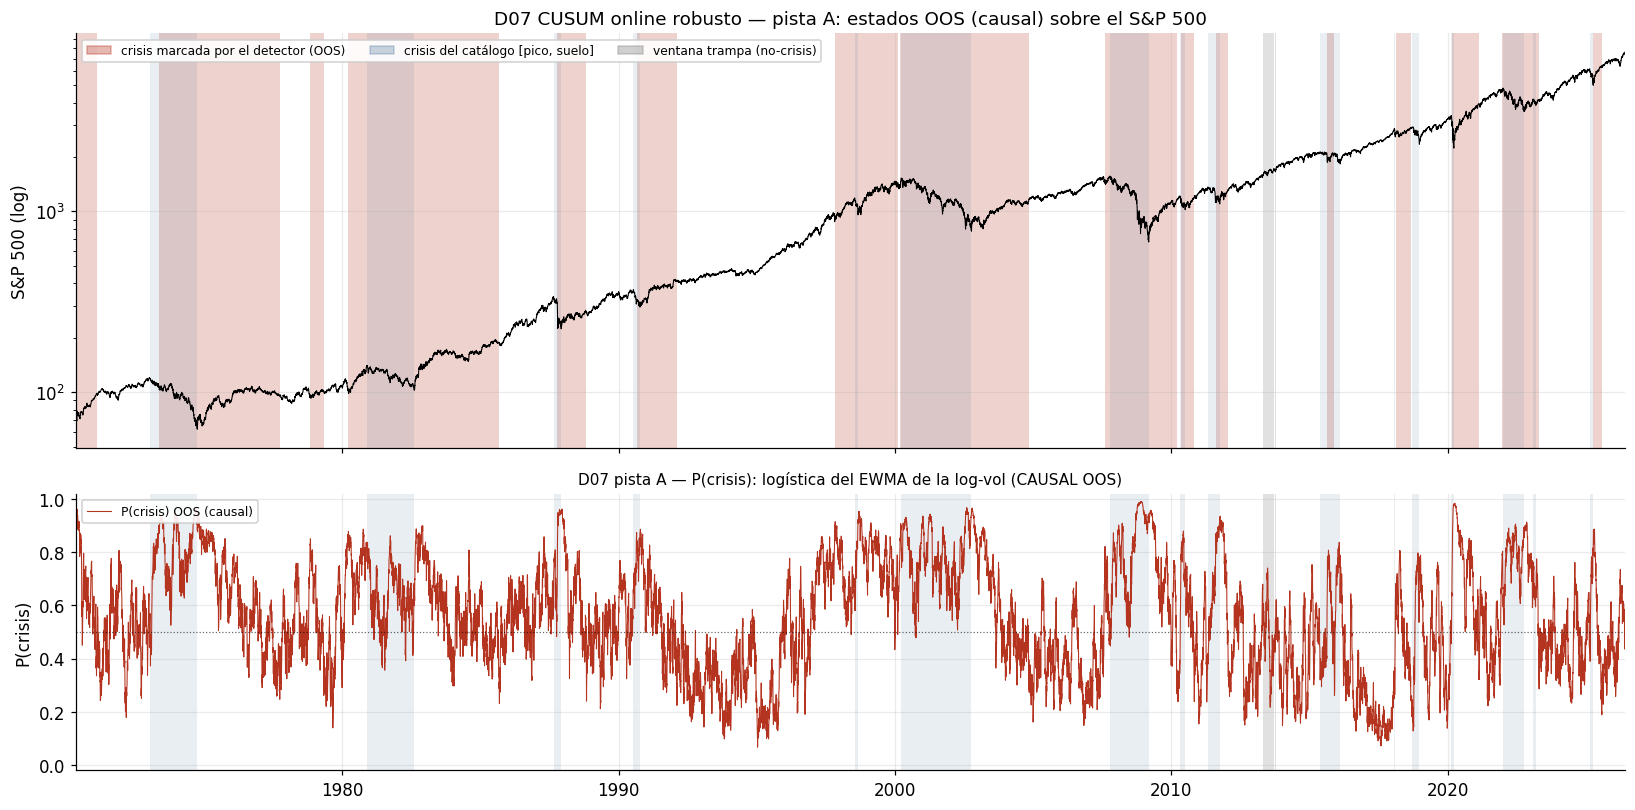

figura -> results/detectores/f6_changepoint/D07_B_estados_oos.png


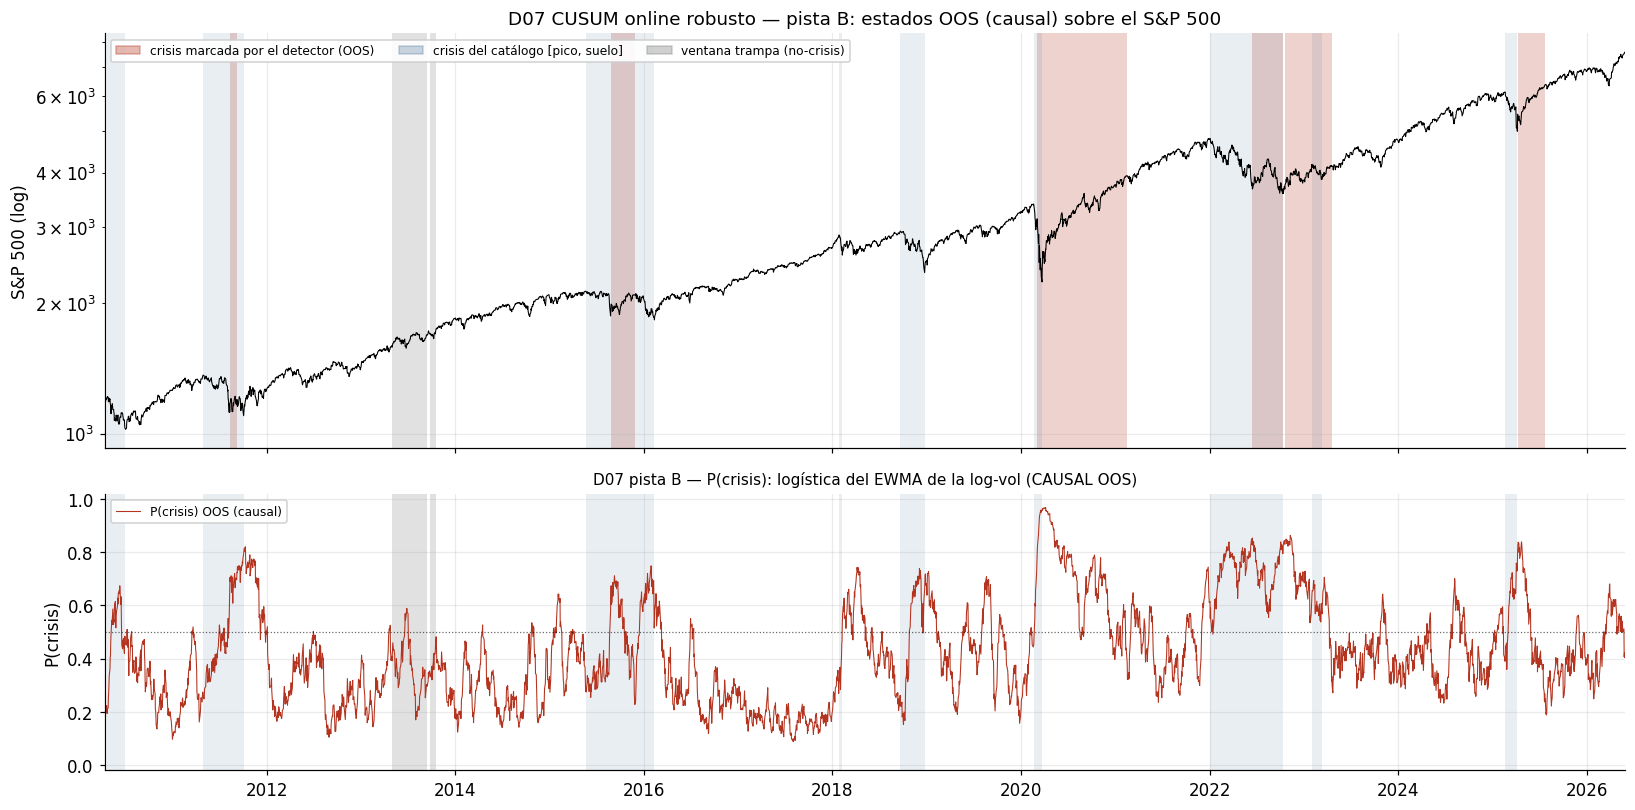

In [8]:
for t in PISTAS:
    figura_estados(t, 'D07', titulo_diag=f'D07 pista {t} — P(crisis): logística del EWMA de la log-vol (CAUSAL OOS)')

### 4.2 Diagnóstico propio: el mecanismo CUSUM (ilustrativo, no causal)

Se ajusta D07 **una vez sobre toda la muestra** de la pista (base mediana/MAD de toda la
serie: ve el futuro) y se reconstruyen sus acumuladores. Arriba, el estadístico $z_t$ con la
holgura $k$; en medio, el acumulador activo en espejo ($C^+$ hacia arriba en calma,
$-C^-$ hacia abajo en crisis) con las compuertas $\pm h$; abajo, los estados in-sample
frente a los OOS del benchmark. La celda comprueba que la reconstrucción coincide con el
autómata del detector y mide el acuerdo in-sample/OOS.

Pista A: base in-sample mediana(log|r|)=-5.336, escala=1.4826*MAD=1.083; 30 conmutaciones in-sample; acuerdo estado in-sample vs OOS = 87.9%


figura -> results/detectores/f6_changepoint/D07_A_cusum_acumuladores.png


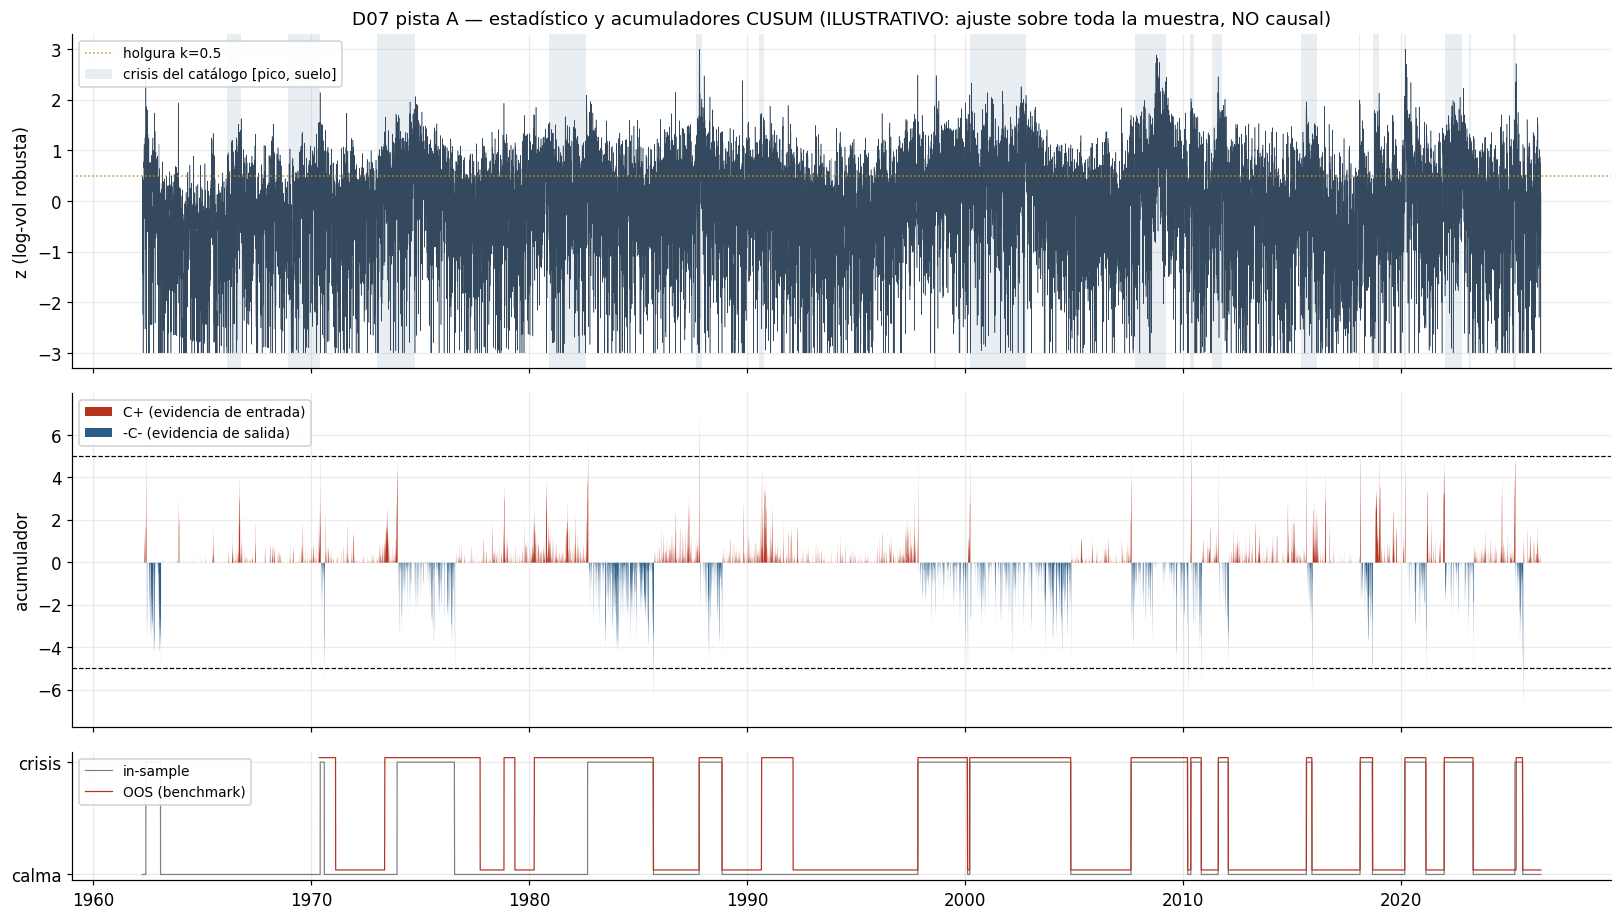

Pista B: base in-sample mediana(log|r|)=-5.247, escala=1.4826*MAD=1.154; 14 conmutaciones in-sample; acuerdo estado in-sample vs OOS = 94.7%


figura -> results/detectores/f6_changepoint/D07_B_cusum_acumuladores.png


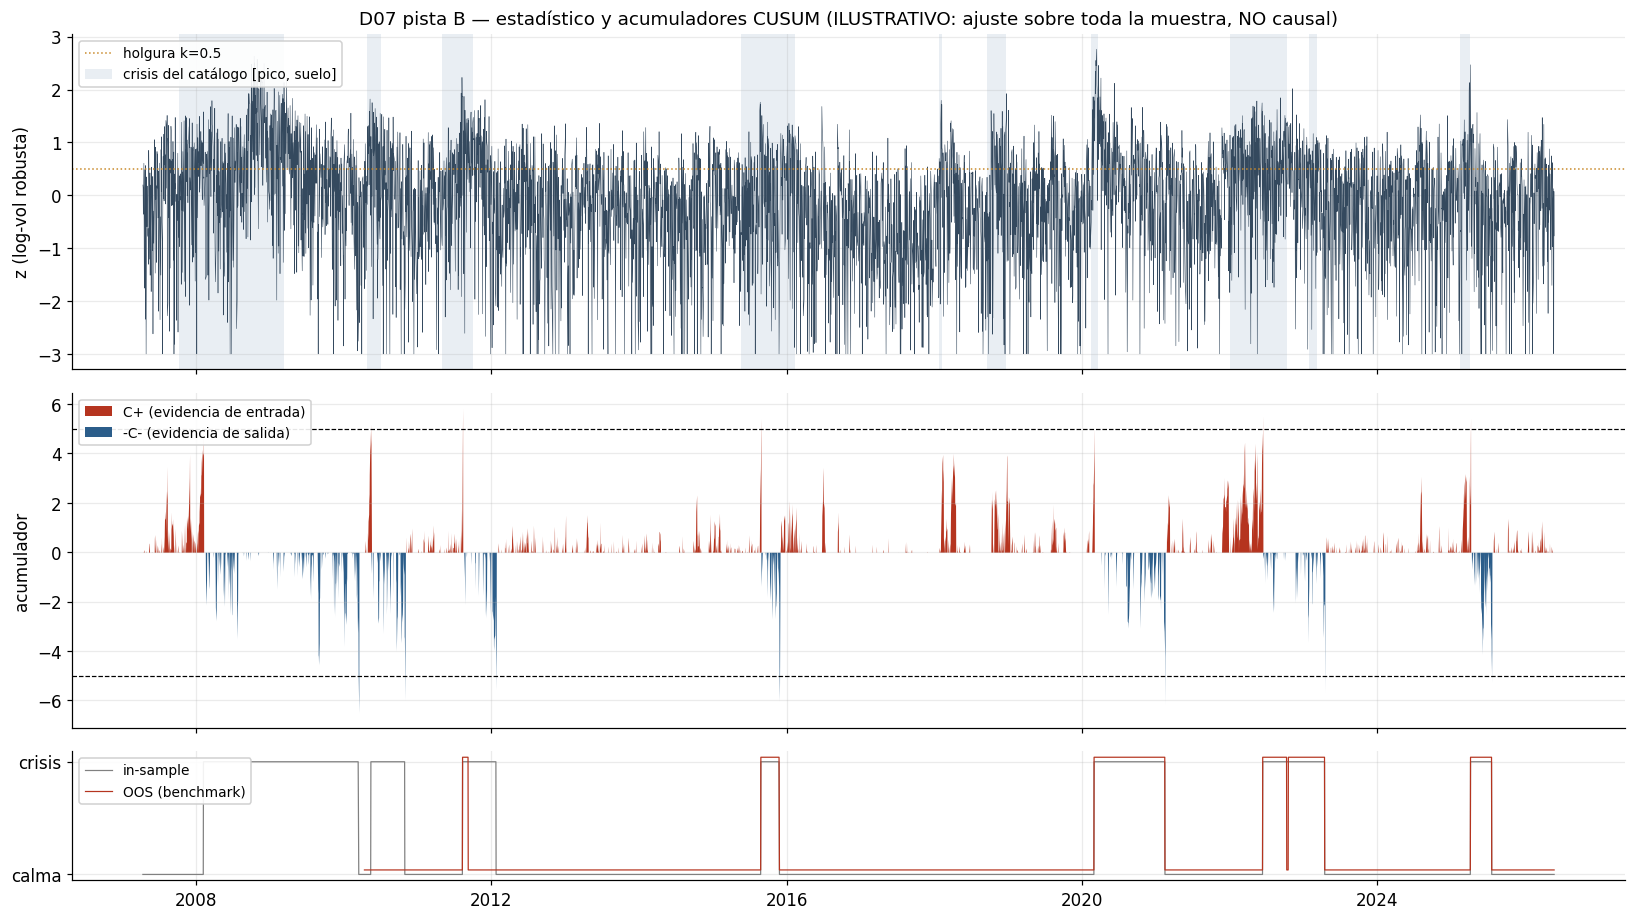

In [9]:
def cusum_in_sample(t):
    spec = SPECS[(t, 'D07')]
    panel_t = DATOS[t]
    X = panel_t.loc[common_track_index(t, panel_t), list(spec.features)]
    mkt = panel_t['SP500_ret'].reindex(X.index)
    det = spec.factory().fit(X)
    det.label_states_economically(X, market_returns=mkt)
    r = det._returns(X)
    z = pd.Series(det._standardize(det._raw_stat(r)), index=r.index)
    activo = np.zeros(len(z)); estado_int = np.zeros(len(z), dtype=int)
    s, cu, cd = 0, 0.0, 0.0
    for i, zt in enumerate(z.to_numpy()):
        if np.isfinite(zt):
            if s == 0:
                cu = max(0.0, cu + zt - det.k); activo[i] = cu
                if cu > det.h:
                    s, cu, cd = 1, 0.0, 0.0
            else:
                cd = max(0.0, cd - zt - det.k); activo[i] = -cd
                if cd > det.h:
                    s, cu, cd = 0, 0.0, 0.0
        estado_int[i] = s
    assert np.array_equal(estado_int, det._cusum_states(z.to_numpy())), 'reconstrucción != autómata de D07'
    estados = pd.Series(det.predict(X), index=X.index)  # orden canónico (crisis = n_states-1)
    return det, z, pd.Series(activo, index=z.index), estados


CUSUM_IS = {}
for t in PISTAS:
    configure_evaluation(t)
    det, z, activo, estados_is = cusum_in_sample(t)
    CUSUM_IS[t] = (det, z, activo, estados_is)
    oos = PANELES[(t, 'D07')]['state']
    comun = oos.index.intersection(estados_is.index)
    acuerdo = float((oos.loc[comun] == estados_is.loc[comun]).mean())
    n_conm = int((estados_is.diff().fillna(0) != 0).sum())
    print(f'Pista {t}: base in-sample mediana(log|r|)={det._center:.3f}, escala=1.4826*MAD={det._scale:.3f}; '
          f'{n_conm} conmutaciones in-sample; acuerdo estado in-sample vs OOS = {acuerdo:.1%}')

    fig, axes = plt.subplots(3, 1, figsize=(15, 8.5), sharex=True,
                             gridspec_kw={'height_ratios': [1.3, 1.3, 0.5]})
    axes[0].plot(z.index, z.values, color='#34495e', lw=0.35)
    axes[0].axhline(det.k, color=viz.C_SHORT, ls=':', lw=1, label=f'holgura k={det.k:g}')
    sombrear_crisis(axes[0]); axes[0].set_ylabel('z (log-vol robusta)')
    axes[0].legend(loc='upper left', framealpha=0.9)
    axes[0].set_title(f'D07 pista {t} — estadístico y acumuladores CUSUM (ILUSTRATIVO: ajuste sobre toda la muestra, NO causal)')
    axes[1].fill_between(activo.index, 0, activo.clip(lower=0), color=viz.C_CRISIS, lw=0, label='C+ (evidencia de entrada)')
    axes[1].fill_between(activo.index, 0, activo.clip(upper=0), color=viz.C_LONG, lw=0, label='-C- (evidencia de salida)')
    for sgn in (1, -1):
        axes[1].axhline(sgn * det.h, color='black', ls='--', lw=0.8)
    axes[1].set_ylabel('acumulador'); axes[1].legend(loc='upper left', framealpha=0.9)
    axes[2].plot(estados_is.index, estados_is.values, color='grey', lw=0.8, label='in-sample')
    axes[2].plot(oos.index, oos.values + 0.04, color=viz.C_CRISIS, lw=0.8, label='OOS (benchmark)')
    axes[2].set_yticks([0, 1], ['calma', 'crisis']); axes[2].legend(loc='upper left', framealpha=0.9)
    fig.tight_layout(); guardar(fig, f'D07_{t}_cusum_acumuladores'); plt.show()

**Oráculo PELT (offline, NO causal).** Si el extra opcional `ruptures` está instalado
(`pip install -e .[changepoint]`), se segmenta la log-volatilidad de toda la serie con PELT
(coste L2) y se mide el retardo entre cada entrada en crisis del CUSUM in-sample y el cambio
PELT inmediatamente anterior: es el precio, en sesiones, de no ver el futuro. Nunca entra en
la evaluación.

In [10]:
PELT = dict(model='l2', min_size=40, jump=5, pen=25)  # configuración del oráculo de la Capa 1
try:
    import ruptures as rpt
except ImportError:
    rpt = None
    print('ruptures no está instalado: se omite el oráculo PELT (pip install -e .[changepoint]).')

if rpt is not None:
    for t in PISTAS:
        det, z, activo, estados_is = CUSUM_IS[t]
        r = det._returns(DATOS[t].loc[z.index])
        logvol = np.log(r.abs().to_numpy() + 1e-6).reshape(-1, 1)
        bkps = rpt.Pelt(model=PELT['model'], min_size=PELT['min_size'], jump=PELT['jump']).fit(logvol).predict(pen=PELT['pen'])
        pelt_cp = pd.DatetimeIndex([z.index[min(b, len(z) - 1)] for b in bkps[:-1]])
        v = estados_is.to_numpy(); cs = det.crisis_state
        entradas = estados_is.index[np.where((v[1:] == cs) & (v[:-1] != cs))[0] + 1]
        pos = pd.Series(np.arange(len(z)), index=z.index)
        retardos = [int(pos[e] - pos[pelt_cp[pelt_cp <= e][-1]]) for e in entradas if (pelt_cp <= e).any()]
        if not retardos:
            print(f'Pista {t}: sin pares entrada CUSUM / cambio PELT previo.')
            continue
        print(f'Pista {t}: PELT {len(pelt_cp)} cambios; CUSUM {len(entradas)} entradas en crisis; '
              f'retardo causal mediano vs cambio PELT previo = {np.median(retardos):.0f} sesiones '
              f'(p25={np.percentile(retardos, 25):.0f}, p75={np.percentile(retardos, 75):.0f})')
        fig, ax = plt.subplots(figsize=(15, 3.8))
        ax.plot(z.index, z.values, color='#34495e', lw=0.3)
        for d in pelt_cp:
            ax.axvline(d, color='#7d3c98', lw=0.6, alpha=0.6)
        for d in entradas:
            ax.axvline(d, color=viz.C_CRISIS, lw=1.0)
        ax.set_title(f'D07 pista {t} — PELT (morado, oráculo offline NO causal) vs entradas CUSUM (rojo, online)')
        fig.tight_layout(); guardar(fig, f'D07_{t}_cusum_vs_pelt'); plt.show()

ruptures no está instalado: se omite el oráculo PELT (pip install -e .[changepoint]).


### 4.3 Cobertura por crisis, retardo de confirmación y lead/lag

Por crisis OOS de la pista: cobertura (fracción de días de `[pico, suelo]` marcados, con
IC90 por *block bootstrap*), detección por evento (racha mínima de `min_run` sesiones, la
unidad del ranking ADR-003), **retardo de confirmación** (sesiones desde el pico hasta el
primer día en crisis; 0 = ya estaba en crisis) y **lead/lag** frente al suelo (señal
sostenida de $p^{\text{crisis}}$). Las crisis que caen en el entrenamiento inicial no se evalúan.

**Cómo leer el lead/lag.** `metricas.lead_lag` toma el **primer** cruce sostenido de
$p^{\text{crisis}}$ dentro de las sesiones previas al suelo (ventana de búsqueda de longitud
fija). Un valor negativo **no** equivale a anticipación: si coincide con el tope de la ventana,
la señal ya estaba encendida al empezar la búsqueda (**saturado**); si es anterior al pico de la
crisis, es una alarma previa (estado ya activo o activación anterior), no una anticipación
atribuible a la crisis. Solo los valores **entre pico y suelo** miden una reacción a la caída.
La columna `lectura_lead_lag` clasifica cada crisis (`inf.clasificar_lead_lag`). Recuérdese
además que para D07 se calcula sobre la $p^{\text{crisis}}$ (EWMA), no sobre el estado CUSUM.

Pista A: 17 crisis evaluadas OOS | activación en trampas: taper_2013=0.0%, debtceiling_2013=0.0%


,pico,suelo,cobertura,ic_lo,ic_hi,detectada,lead_lag_dias,retardo_confirmacion,sesiones_pico_suelo,lectura_lead_lag
crisis,,,,,,,,,,
bear_1969_70,1968-11-29,1970-05-26,100.0%,100.0%,100.0%,1,-10,0,10,saturado
oil_stagflation_1973,1973-01-11,1974-10-03,80.8%,72.1%,89.0%,1,-252,84,436,saturado
volcker_1980_82,1980-11-28,1982-08-12,100.0%,100.0%,100.0%,1,-251,0,430,entre pico y suelo
black_monday_1987,1987-08-25,1987-12-04,48.6%,21.5%,73.0%,1,-248,37,71,antes del pico
gulf_war_sl_1990,1990-07-16,1990-10-11,52.4%,25.4%,80.2%,1,-251,30,62,antes del pico
ltcm_russia_1998,1998-07-17,1998-08-31,100.0%,100.0%,100.0%,1,-252,0,31,saturado
dotcom_2000_02,2000-03-24,2002-10-09,100.0%,100.0%,100.0%,1,-252,0,637,saturado
gfc_2007_09,2007-10-09,2009-03-09,100.0%,100.0%,100.0%,1,-252,0,355,saturado
flash_crash_euro1_2010,2010-04-23,2010-07-02,80.0%,59.0%,100.0%,1,-252,10,49,saturado


figura -> results/detectores/f6_changepoint/D07_A_cobertura_crisis.png


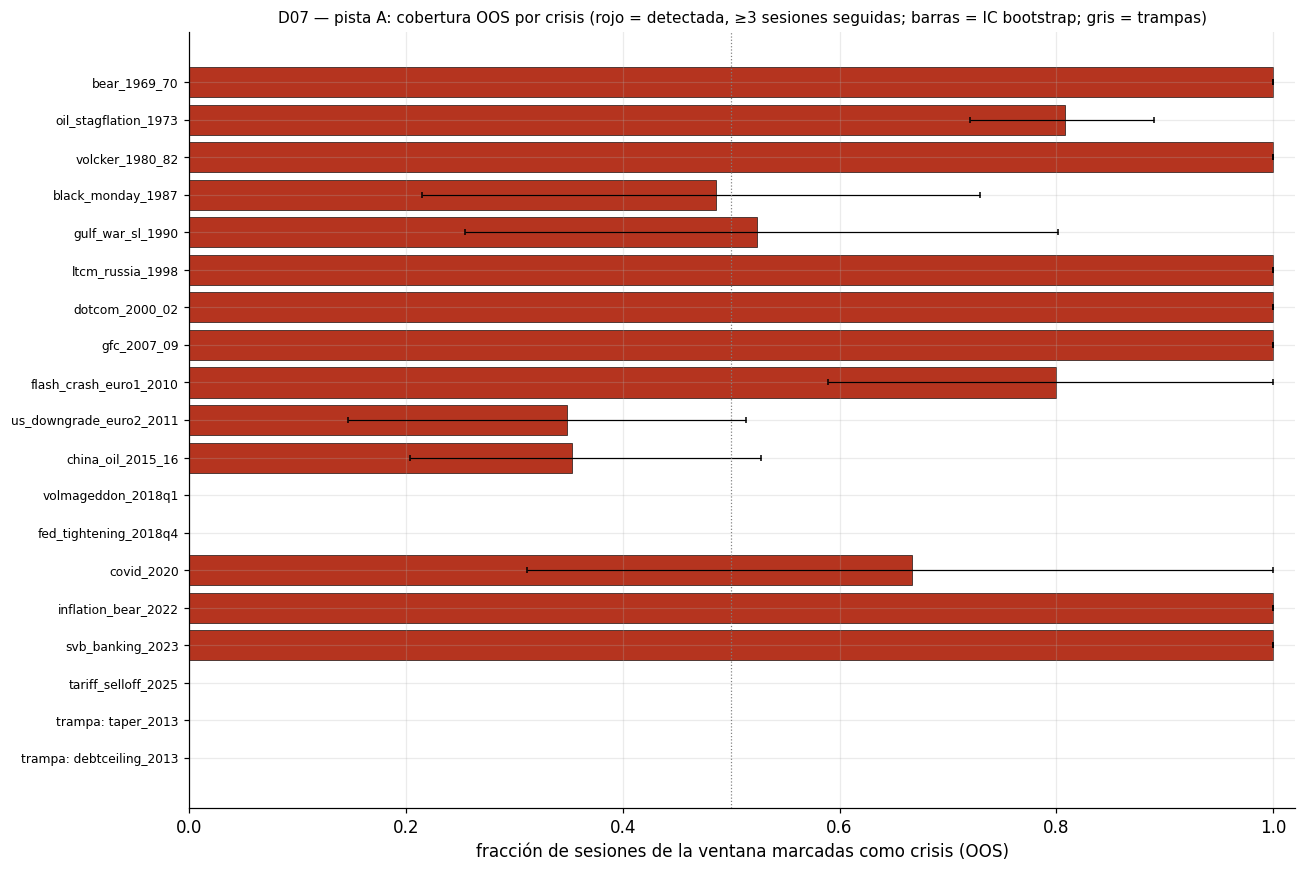

Pista B: 9 crisis evaluadas OOS | activación en trampas: taper_2013=0.0%, debtceiling_2013=0.0%


,pico,suelo,cobertura,ic_lo,ic_hi,detectada,lead_lag_dias,retardo_confirmacion,sesiones_pico_suelo,lectura_lead_lag
crisis,,,,,,,,,,
flash_crash_euro1_2010,2010-04-23,2010-07-02,0.0%,0.0%,0.0%,0,-38,—,49,entre pico y suelo
us_downgrade_euro2_2011,2011-04-29,2011-10-03,17.4%,2.8%,34.9%,1,-39,72,108,entre pico y suelo
china_oil_2015_16,2015-05-21,2016-02-11,34.8%,20.7%,51.1%,1,-252,68,183,saturado
volmageddon_2018q1,2018-01-26,2018-02-08,0.0%,0.0%,0.0%,0,—,—,9,sin señal
fed_tightening_2018q4,2018-09-20,2018-12-24,0.0%,0.0%,0.0%,0,-220,—,65,antes del pico
covid_2020,2020-02-19,2020-03-23,62.5%,25.0%,100.0%,1,-207,9,23,antes del pico
inflation_bear_2022,2022-01-03,2022-10-12,41.8%,26.0%,56.1%,1,-252,114,195,saturado
svb_banking_2023,2023-02-02,2023-03-13,100.0%,100.0%,100.0%,1,-252,0,26,saturado
tariff_selloff_2025,2025-02-19,2025-04-08,0.0%,0.0%,0.0%,0,-233,—,34,antes del pico


figura -> results/detectores/f6_changepoint/D07_B_cobertura_crisis.png


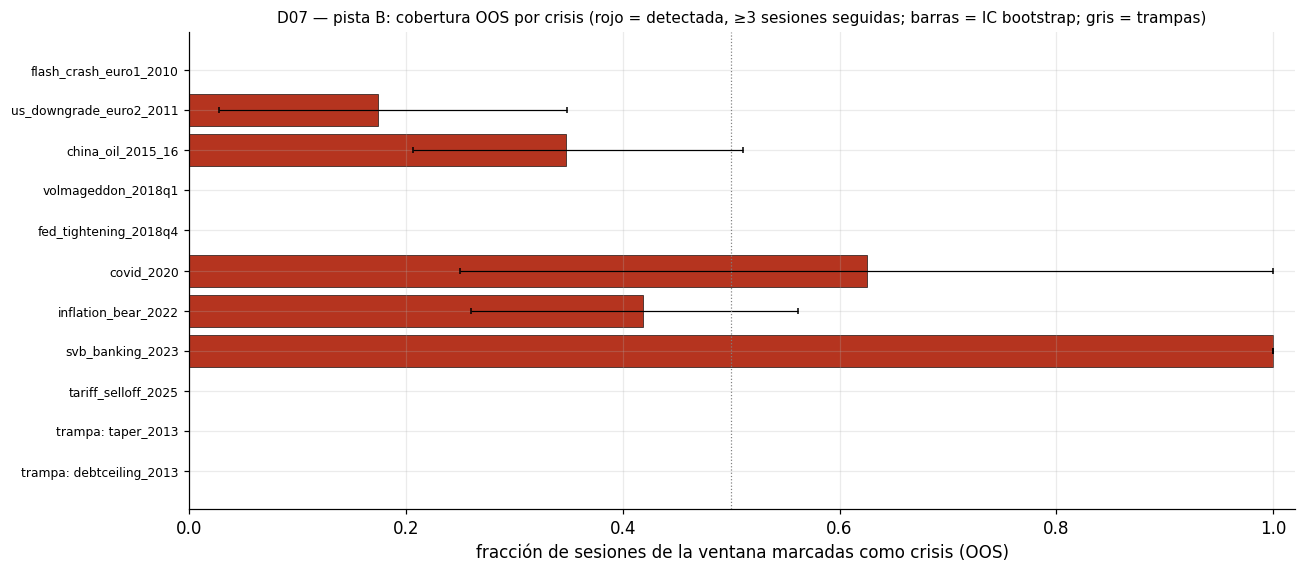

In [11]:
TABLAS_CRISIS = {}
for t in PISTAS:
    tab, trampas = tabla_crisis(t, 'D07')
    tab = tab.join(retardo_confirmacion(t, 'D07'))
    tab = inf.clasificar_lead_lag(tab, PANELES[(t, 'D07')].index)
    TABLAS_CRISIS[t] = (tab, trampas)
    print(f'Pista {t}: {len(tab)} crisis evaluadas OOS | activación en trampas: '
          + ', '.join(f'{k}={v:.1%}' for k, v in trampas.items()))
    display(tab.style.format({'cobertura': '{:.1%}', 'ic_lo': '{:.1%}', 'ic_hi': '{:.1%}',
                              'detectada': '{:.0f}', 'lead_lag_dias': '{:.0f}',
                              'retardo_confirmacion': '{:.0f}'}, na_rep='—'))
    figura_cobertura(t, 'D07')

### 4.4 Métricas y puesto en el ranking de detección ADR-003

`score_deteccion` es la F1 entre recall por evento y precisión diaria; el nivel
(`elegible`, `precision_no_supera_azar`, `parpadeo`, `degenerado`) se ordena antes que el
score. Las métricas proceden del CSV cacheado del benchmark.

In [12]:
RESUMEN = pd.DataFrame({f'D07 pista {t}': resumen_metricas(t, 'D07') for t in PISTAS})
display(resumen_ranking(DETECTORES).round(4))
display(RESUMEN)
for t in PISTAS:
    tab = TABLAS_CRISIS[t][0]
    ll = tab['lead_lag_dias'].dropna()
    lect = tab['lectura_lead_lag'].value_counts()
    print(f'Pista {t}: lead/lag con señal sostenida en {len(ll)} de {len(tab)} crisis; mediana {ll.median():.0f} '
          f'sesiones (ventana de búsqueda {inf.lookback_lead_lag()}). Lectura: '
          + ', '.join(f'{k} {int(lect.get(k, 0))}' for k in ('saturado', 'antes del pico', 'entre pico y suelo', 'sin señal'))
          + f'. Retardo de confirmación mediano desde el pico: {tab["retardo_confirmacion"].median():.0f} sesiones '
            f'(ya en crisis el día del pico en {int((tab["retardo_confirmacion"] == 0).sum())}).')

,,puesto_deteccion,de,nivel_etiqueta,score_deteccion,det_event_recall,det_n_detectados,det_n_eventos,det_precision,det_lift_precision,det_base_rate,det_marked_rate,det_mean_crisis_run,mean_crisis_coverage,false_alarm_rate,mean_trap_activation,switching_rate,mean_regime_duration,label_stability,elapsed_seconds
pista,id,,,,,,,,,,,,,,,,,,,
A,D07,8,12,elegible,0.4693,0.8235,14,17,0.3282,1.6921,0.1939,0.4896,432.5,0.6463,0.6718,0.0,0.0022,441.6562,1.0000,105.4821
B,D07,7,12,elegible,0.4257,0.5556,5,9,0.3450,1.9977,0.1727,0.1478,100.0,0.2851,0.6550,0.0,0.0030,312.2308,0.9951,12.0896


,D07 pista A,D07 pista B
n_oos,14133,4059
oos_start,1970-05-12,2010-04-12
oos_end,2026-05-29,2026-05-29
det_event_recall,0.823529,0.555556
det_n_detectados,14,5
det_n_eventos,17,9
det_precision,0.328179,0.345
det_lift_precision,1.69214,1.997653
det_marked_rate,0.489634,0.14782
det_day_recall,0.82853,0.295292


Pista A: lead/lag con señal sostenida en 16 de 17 crisis; mediana -252 sesiones (ventana de búsqueda 252). Lectura: saturado 10, antes del pico 5, entre pico y suelo 1, sin señal 1. Retardo de confirmación mediano desde el pico: 4 sesiones (ya en crisis el día del pico en 7).
Pista B: lead/lag con señal sostenida en 8 de 9 crisis; mediana -226 sesiones (ventana de búsqueda 252). Lectura: saturado 3, antes del pico 3, entre pico y suelo 2, sin señal 1. Retardo de confirmación mediano desde el pico: 68 sesiones (ya en crisis el día del pico en 1).


<a id="s5"></a>
## 5. Comparación intra-familia

F6 tiene un solo detector en el benchmark, así que la comparación útil es doble: (a) el
**coste** —la variante gaussiana (retorno², media/desviación), que es la pregunta central de
la familia ante colas gordas—, reevaluada con el **mismo protocolo** que `run_one` (índice
común, train inicial, `step`, `market_returns`, métricas `det_*`) y situada
hipotéticamente en el ranking de su pista; y (b) la misma configuración en la **pista A**
(historia larga, muchas crisis) frente a la **B** (panel moderno: más features pero menos
eventos). `EJECUTAR_ABLACION = False` omite (a); el panel de la variante se guarda como caché local
en `results/detectores/f6_changepoint/` (sin huella: `FORZAR_ABLACION = True` si cambia algo).

In [13]:
def evaluar_variante(t, fabrica, features, *, step, expanding, nombre, recalcular=False):
    """Walk-forward causal de una variante NO registrada con el MISMO protocolo que run_one
    (índice común de la pista, train inicial, step, market_returns, evaluate + det_*).
    El panel OOS se guarda como caché local en results/detectores/<familia>/ (sin huella:
    pon recalcular=True si cambia el código o los datos; label_stability queda NaN al leerlo)."""
    configure_evaluation(t)
    panel_t = DATOS[t]
    X = panel_t.loc[common_track_index(t, panel_t), list(features)]
    mkt = panel_t['SP500_ret'].reindex(X.index)
    n_train = DEFAULT_TRAIN_DAYS[t]
    ruta = FIG_DIR / f'variante_{nombre}_{t}.parquet'
    if ruta.is_file() and not recalcular:
        wf = pd.read_parquet(ruta)
    else:
        wf = ev.walk_forward(fabrica, X, market_returns=mkt, train_size=n_train, min_train=n_train,
                             step=step, expanding=expanding)
        copia = wf.copy(); copia.attrs = {}
        copia.to_parquet(ruta)
    final = fabrica()
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        final.fit(X)
    final.label_states_economically(X, market_returns=mkt)
    fila = ev.results_table([ev.evaluate(final, wf, market_returns=mkt, X_full=X)])
    for k, v in detection_summary(wf['state'].eq(final.crisis_state), dict(ev.CRISIS_WINDOWS)).items():
        fila[k] = v
    fila.insert(0, 'id', nombre)
    fila.insert(0, 'pista', t)
    fila = rk.add_comparison_metrics(fila)
    return wf, fila.iloc[0]


def puesto_hipotetico(t, fila):
    """Puesto que ocuparía la variante si se añadiera al ranking ADR-003 de su pista."""
    if not MATRIZ_COMPLETA:
        return np.nan, 'n/d (matriz 2x12 no vigente)'
    base = METRICAS_TODAS[METRICAS_TODAS['pista'].eq(t)]
    r = rk.rank_detection(pd.concat([base, pd.DataFrame([fila.to_dict()])], ignore_index=True),
                          output_dir=OUTPUT_DIR)
    r = r.set_index('id').loc[fila['id']]
    return int(r['puesto_deteccion']), r['nivel_etiqueta']


COLS_CONTRASTE = ['det_event_recall', 'det_precision', 'det_lift_precision', 'det_marked_rate',
                  'det_mean_crisis_run', 'mean_crisis_coverage', 'false_alarm_rate', 'mean_trap_activation',
                  'switching_rate', 'mean_regime_duration']

In [14]:
EJECUTAR_ABLACION = True
FORZAR_ABLACION = False
filas = []
PANELES_VAR = {}
for t in PISTAS:
    spec = SPECS[(t, 'D07')]
    oficial = METRICAS.loc[(t, 'D07')]
    fila_of = oficial.reindex(COLS_CONTRASTE).to_dict()
    fila_of.update({'pista': t, 'variante': 'robusto (registrado)',
                    'score_deteccion': RANK_FAM.loc[(t, 'D07'), 'score_deteccion'],
                    'puesto': f"{int(RANK_FAM.loc[(t, 'D07'), 'puesto_deteccion'])} de {N_RANK[t]}",
                    'nivel': RANK_FAM.loc[(t, 'D07'), 'nivel_etiqueta']})
    filas.append(fila_of)
    if EJECUTAR_ABLACION:
        params_g = {**spec.params, 'cost': 'gaussian'}
        wf_g, fila_g = evaluar_variante(t, lambda p=params_g: ChangepointOnline(**p), spec.features,
                                        step=spec.step, expanding=spec.expanding,
                                        nombre='D07_gauss', recalcular=FORZAR_ABLACION)
        PANELES_VAR[t] = wf_g
        puesto, nivel = puesto_hipotetico(t, fila_g)
        d = fila_g.reindex(COLS_CONTRASTE).to_dict()
        d.update({'pista': t, 'variante': 'gaussiano (ablación)',
                  'score_deteccion': rk.detection_score(fila_g['det_precision'], fila_g['det_event_recall']),
                  'puesto': f'{puesto} de {N_RANK[t] + 1} (hipotético)' if puesto == puesto else nivel,
                  'nivel': nivel})
        filas.append(d)
CONTRASTE = pd.DataFrame(filas).set_index(['pista', 'variante'])
display(CONTRASTE.style.format(precision=3))

figura -> results/detectores/f6_changepoint/F6_comparativa_robusto_vs_gaussiano.png


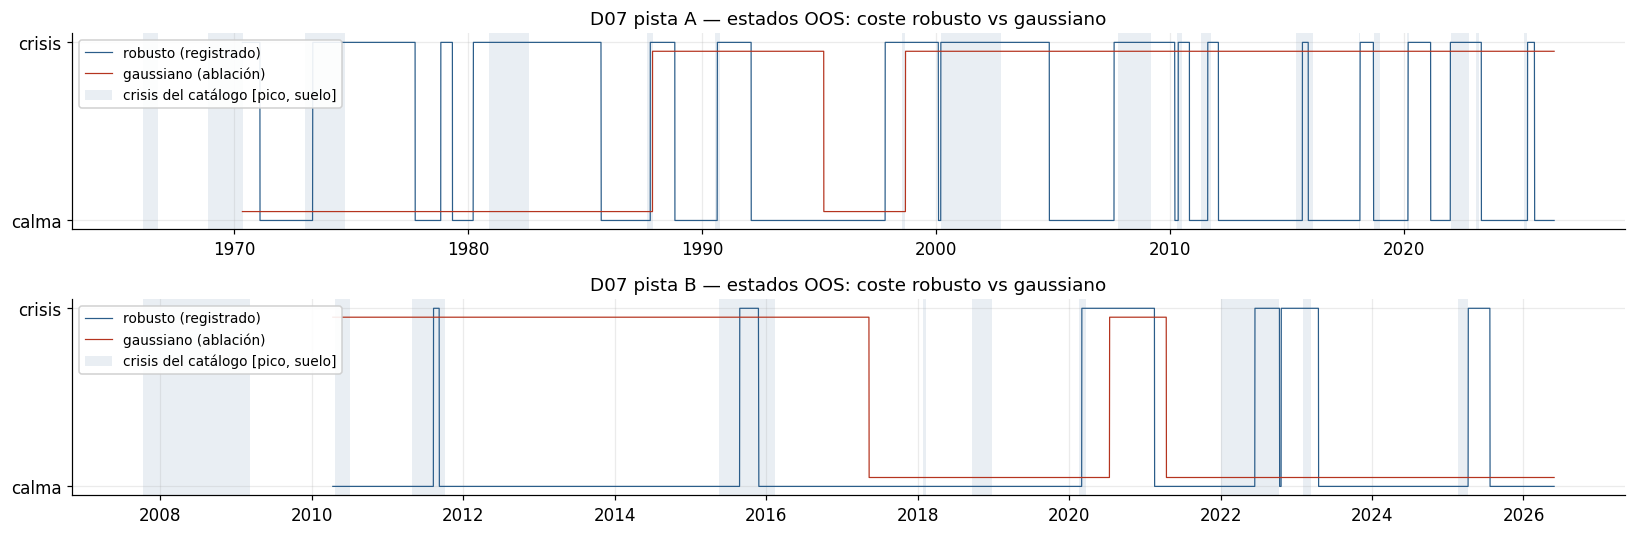

figura -> results/detectores/f6_changepoint/F6_comparativa_contraste_coste.png


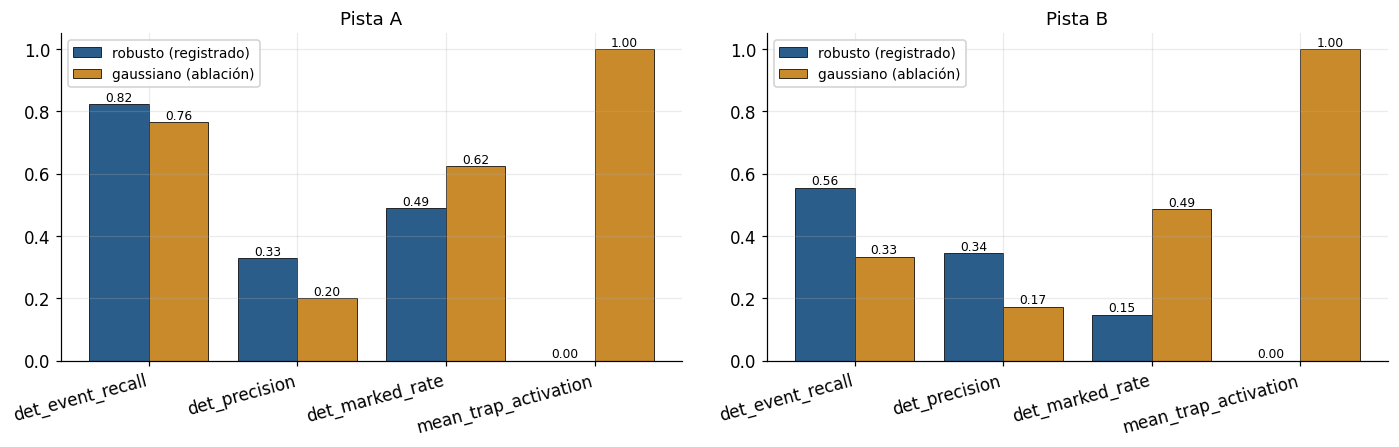

In [15]:
if EJECUTAR_ABLACION:
    fig, axes = plt.subplots(len(PISTAS), 1, figsize=(15, 2.2 * len(PISTAS) + 0.6), sharex=False)
    for ax, t in zip(np.atleast_1d(axes), PISTAS):
        configure_evaluation(t)
        rob = PANELES[(t, 'D07')]['state']; gau = PANELES_VAR[t]['state']
        ax.plot(rob.index, rob.values, color=viz.C_LONG, lw=0.8, label='robusto (registrado)')
        ax.plot(gau.index, gau.values * 0.9 + 0.05, color=viz.C_CRISIS, lw=0.8, label='gaussiano (ablación)')
        sombrear_crisis(ax); ax.set_yticks([0, 1], ['calma', 'crisis'])
        ax.set_title(f'D07 pista {t} — estados OOS: coste robusto vs gaussiano'); ax.legend(loc='upper left', framealpha=0.9)
    fig.tight_layout(); guardar(fig, 'F6_comparativa_robusto_vs_gaussiano'); plt.show()

    metricas_barras = ['det_event_recall', 'det_precision', 'det_marked_rate', 'mean_trap_activation']
    fig, axes = plt.subplots(1, len(PISTAS), figsize=(13, 4.2))
    for ax, t in zip(np.atleast_1d(axes), PISTAS):
        part = CONTRASTE.loc[t]
        viz.plot_grouped_bars(metricas_barras, {v: part.loc[v, metricas_barras].astype(float).tolist() for v in part.index},
                              ax=ax, title=f'Pista {t}', value_labels=True, rotation=15)
    fig.tight_layout(); guardar(fig, 'F6_comparativa_contraste_coste'); plt.show()

In [16]:
ENTRE_PISTAS = pd.DataFrame({t: {
    'OOS': f"{METRICAS.loc[(t, 'D07'), 'oos_start']} -> {METRICAS.loc[(t, 'D07'), 'oos_end']}",
    'crisis evaluadas': len(TABLAS_CRISIS[t][0]),
    'recall por evento': METRICAS.loc[(t, 'D07'), 'det_event_recall'],
    'precisión': METRICAS.loc[(t, 'D07'), 'det_precision'],
    'lift': METRICAS.loc[(t, 'D07'), 'det_lift_precision'],
    'fracción marcada': METRICAS.loc[(t, 'D07'), 'det_marked_rate'],
    'duración media régimen': METRICAS.loc[(t, 'D07'), 'mean_regime_duration'],
    'puesto ADR-003': f"{int(RANK_FAM.loc[(t, 'D07'), 'puesto_deteccion'])} de {N_RANK[t]}",
} for t in PISTAS})
display(ENTRE_PISTAS)

,A,B
OOS,1970-05-12 -> 2026-05-29,2010-04-12 -> 2026-05-29
crisis evaluadas,17,9
recall por evento,0.823529,0.555556
precisión,0.328179,0.345
lift,1.69214,1.997653
fracción marcada,0.489634,0.14782
duración media régimen,441.65625,312.230769
puesto ADR-003,8 de 12,7 de 12


<a id="s6"></a>
## 6. Hallazgos de la Capa 1 (v1) y qué se mantiene / cambia en v2

**Lo que concluyó la Capa 1** (ficha `docs/detectores/D07_changepoint_online.md`, notebook
`capa1-final:capa1_exploracion/notebooks/07_changepoint_online.ipynb`, tag git `capa1-final`), con la hipótesis del
CHECKPOINT 2 *"detección temprana pero riesgo de falsas alarmas con outliers; preferir
robusto frente al CUSUM gaussiano"*:

- **Causalidad verificada**: ocultar el futuro no cambiaba ningún día del bloque (patrón
  *burn-in*); PELT solo como oráculo.
- **Detección temprana**: lead/lag sostenido negativo en todas las crisis canónicas de
  entonces (la señal de volatilidad se activa en la caída, antes del suelo del precio).
  *(Lectura v1. Varios de esos valores eran el tope de la ventana de búsqueda, es decir,
  señal ya encendida y no anticipación; la celda siguiente los cuenta y §6.1 da el veredicto
  v2.)*
- **Coste gaussiano degenerado**: con $r^2$ el autómata entraba en crisis con el primer
  shock y no salía (alarma casi permanente, trampas al máximo); el coste robusto recuperaba
  regímenes limpios, trampas a cero y episodios largos sin perder cobertura.
- **Poco *flickering***: la histéresis de $h$ daba episodios muy largos.
- **Falsas alarmas "legítimas"**: su `false_alarm_rate` global era alto porque marcaba
  episodios de alta volatilidad reales fuera de las pocas ventanas canónicas.

**Qué cambia en v2.** El código del detector es el mismo (congelado, solo cambian imports);
cambian el marco y el juez: (i) dos pistas —A con historia larga y B con el panel moderno—
con muchas más ventanas de crisis `[pico, suelo]` congeladas en
`configs/benchmark_spec.yaml`, de modo que aquellas "falsas alarmas legítimas" pasan a ser
crisis del ground-truth; (ii) índice OOS común a todos los detectores; (iii) contexto de
predicción ADR-003; (iv) ranking por **detección de eventos** (F1 recall-precisión con
niveles), no por media de rangos. La celda siguiente pone lado a lado las métricas de la
Capa 1 (CSV archivado) y las de v2, y resume qué cambia en la configuración.

In [17]:
V1_CSV = rutas.DOCS / 'historia' / 'capa1' / 'resultados' / 'metrics_07_changepoint_online.csv'
cols = ['n_states', 'ventana_eval', 'n_oos', 'false_alarm_rate', 'switching_rate', 'mean_regime_duration',
        'label_stability']
if V1_CSV.is_file():
    v1 = pd.read_csv(V1_CSV).iloc[0]
    comp = pd.DataFrame({'Capa 1 (v1)': v1.reindex(cols),
                         **{f'v2 pista {t}': METRICAS.loc[(t, 'D07')].reindex(cols) for t in PISTAS}})
    display(comp)
    cov_v1 = {c.removeprefix('cov_'): v1[c] for c in v1.index
              if c.startswith('cov_') and not c.endswith(('_lo', '_hi')) and pd.notna(v1[c])}
    ll_v1 = {c.removeprefix('leadlag_'): v1[c] for c in v1.index if c.startswith('leadlag_') and pd.notna(v1[c])}
    fa_v1 = {c.removeprefix('fa_'): v1[c] for c in v1.index if c.startswith('fa_') and pd.notna(v1[c])}
    print('v1 — crisis evaluadas:', len(cov_v1), '| cobertura:', ', '.join(f'{k}={v:.0%}' for k, v in cov_v1.items()))
    print('v1 — lead/lag (sesiones):', ', '.join(f'{k}={v:.0f}' for k, v in ll_v1.items()),
          f'| en el tope de la ventana de búsqueda (-{inf.lookback_lead_lag()}, saturado): '
          f'{sum(v <= -inf.lookback_lead_lag() for v in ll_v1.values())} de {len(ll_v1)}')
    print('v1 — activación en trampas:', ', '.join(f'{k}={v:.0%}' for k, v in fa_v1.items()))
    for t in PISTAS:
        print(f'v2 pista {t} — crisis evaluadas: {len(TABLAS_CRISIS[t][0])} '
              f'({len(rk.track_crisis_windows(t))} definidas en la pista)')
else:
    print(f'No se encuentra {rel(V1_CSV)}; las métricas v1 están en el tag capa1-final.')

print('Configuración v2 (registro):', {t: dict(SPECS[(t, "D07")].params) for t in PISTAS})
print('Train inicial v2 (sesiones):', {t: DEFAULT_TRAIN_DAYS[t] for t in PISTAS},
      '| step:', {t: SPECS[(t, "D07")].step for t in PISTAS})

,Capa 1 (v1),v2 pista A,v2 pista B
n_states,2,2,2
ventana_eval,1993-03-23→2026-06-12 (n=8278),1970-05-12→2026-05-29 (n=14133),2010-04-12→2026-05-29 (n=4059)
n_oos,8278,14133,4059
false_alarm_rate,0.86743,0.671821,0.655
switching_rate,0.002174,0.002193,0.002956
mean_regime_duration,435.684211,441.65625,312.230769
label_stability,0.99994,1.0,0.995065


v1 — crisis evaluadas: 4 | cobertura: GFC_2008=100%, EuroDebt_2011=67%, COVID_2020=84%, Inflation_2022=77%
v1 — lead/lag (sesiones): GFC_2008=-252, EuroDebt_2011=-252, COVID_2020=-204, Inflation_2022=-252 | en el tope de la ventana de búsqueda (-252, saturado): 3 de 4
v1 — activación en trampas: TaperTantrum_2013=0%, Selloff_Q4_2018=0%
v2 pista A — crisis evaluadas: 17 (18 definidas en la pista)
v2 pista B — crisis evaluadas: 9 (10 definidas en la pista)
Configuración v2 (registro): {'A': {'feature': 'SP500_ret', 'cost': 'robust'}, 'B': {'feature': 'SP500_ret', 'cost': 'robust'}}
Train inicial v2 (sesiones): {'A': 2016, 'B': 756} | step: {'A': 21, 'B': 21}


<a id="s6-cp2"></a>
### 6.1 Hipótesis del CHECKPOINT 2 y veredicto (v1 → v2)

**Hipótesis** (ficha `docs/detectores/D07_changepoint_online.md`, apartado «Hipótesis del
CHECKPOINT 2 para D7 — veredicto»): *«Detección **temprana** (lead/lag) pero **riesgo de falsas
alarmas con outliers**; **preferir kernel/robusto** frente al CUSUM **gaussiano**.»*

**Veredicto v1: se cumple.** Online causal verificado; detección temprana con lead/lag sostenido
negativo en las cuatro crisis (lectura v1: la celda de §6 muestra que varios de esos valores eran
saturación de la ventana de búsqueda, no anticipación); el coste gaussiano degeneraba en alarma permanente (trampas al
máximo) y el robusto las reducía a cero con regímenes limpios.

**Qué dice v2.** La celda siguiente contrasta las tres partes con las cifras vigentes:

1. **Detección temprana.** Se juzga con la lectura del lead/lag de §4.3 (saturado / antes del
   pico / entre pico y suelo) y con el retardo de confirmación desde el pico, no con el signo del
   lead/lag. Un lead/lag saturado o anterior al pico no es anticipación. Además, para D07 se
   calcula sobre la $p^{\text{crisis}}$ (EWMA), no sobre el estado CUSUM. La fusión D7→D8
   (`13_fusion_d07_d08`) contrasta directamente si los avisos de D7 anticipan crisis.
2. **Falsas alarmas con outliers.** Activación en las trampas y precisión del coste gaussiano
   frente al robusto (ablación de §5).
3. **Preferir el coste robusto.** F1 de detección de ambos costes con el mismo protocolo.

In [18]:
# Veredicto v2 por parte de la hipótesis del CHECKPOINT 2 (cifras: TABLAS_CRISIS de §4.3 y CONTRASTE de §5).
lineas = []
for t in PISTAS:
    tab = TABLAS_CRISIS[t][0]
    lect = tab['lectura_lead_lag'].value_counts()
    n_reac = int(lect.get('entre pico y suelo', 0))
    n_prev = int(lect.get('saturado', 0) + lect.get('antes del pico', 0))
    ret = tab['retardo_confirmacion']
    temprana = ('NO se sostiene: el lead/lag negativo es sobre todo saturación o alarma previa al pico, '
                'no anticipación medida' if n_prev > n_reac else
                'se sostiene en parte: la mayoría de las señales llegan entre el pico y el suelo (reacción durante la caída, '
                'no anticipación del pico)')
    texto = (f"- **Pista {t}.** (1) lead/lag: saturado {int(lect.get('saturado', 0))}, antes del pico "
             f"{int(lect.get('antes del pico', 0))}, entre pico y suelo {n_reac}, sin señal {int(lect.get('sin señal', 0))} "
             f"de {len(tab)} crisis; retardo de confirmación mediano {ret.median():.0f} sesiones desde el pico "
             f"(ya en crisis en el pico en {int((ret == 0).sum())}) → «detección temprana» {temprana}.")
    if EJECUTAR_ABLACION:
        rob, gau = CONTRASTE.loc[(t, 'robusto (registrado)')], CONTRASTE.loc[(t, 'gaussiano (ablación)')]
        texto += (f" (2) trampas: robusto {rob['mean_trap_activation']:.0%} vs gaussiano {gau['mean_trap_activation']:.0%}; "
                  f"marca robusto {rob['det_marked_rate']:.0%} vs gaussiano {gau['det_marked_rate']:.0%} → "
                  + ('el riesgo de falsas alarmas del coste gaussiano se confirma'
                     if gau['mean_trap_activation'] > rob['mean_trap_activation'] else 'sin diferencia en trampas')
                  + f". (3) F1 robusto {rob['score_deteccion']:.3f} vs gaussiano {gau['score_deteccion']:.3f} → "
                  + ('preferir el robusto se sostiene' if rob['score_deteccion'] > gau['score_deteccion']
                     else 'el robusto no mejora al gaussiano') + '.')
    lineas.append(texto)
display(Markdown('\n'.join(lineas)))

- **Pista A.** (1) lead/lag: saturado 10, antes del pico 5, entre pico y suelo 1, sin señal 1 de 17 crisis; retardo de confirmación mediano 4 sesiones desde el pico (ya en crisis en el pico en 7) → «detección temprana» NO se sostiene: el lead/lag negativo es sobre todo saturación o alarma previa al pico, no anticipación medida. (2) trampas: robusto 0% vs gaussiano 100%; marca robusto 49% vs gaussiano 62% → el riesgo de falsas alarmas del coste gaussiano se confirma. (3) F1 robusto 0.469 vs gaussiano 0.318 → preferir el robusto se sostiene.
- **Pista B.** (1) lead/lag: saturado 3, antes del pico 3, entre pico y suelo 2, sin señal 1 de 9 crisis; retardo de confirmación mediano 68 sesiones desde el pico (ya en crisis en el pico en 1) → «detección temprana» NO se sostiene: el lead/lag negativo es sobre todo saturación o alarma previa al pico, no anticipación medida. (2) trampas: robusto 0% vs gaussiano 100%; marca robusto 15% vs gaussiano 49% → el riesgo de falsas alarmas del coste gaussiano se confirma. (3) F1 robusto 0.426 vs gaussiano 0.228 → preferir el robusto se sostiene.

<a id="s7"></a>
## 7. Fortalezas, limitaciones y conclusión

**Fortalezas.**
- **Causal por construcción y barato**: una recursión de dos acumuladores; el *burn-in*
  mantiene la continuidad entre folds sin mirar el futuro.
- **Persistencia sin parámetros extra**: el umbral $h$ es a la vez sensibilidad e
  histéresis; episodios largos, estabilidad de etiquetas alta.
- **Robustez a colas**: el coste log|r| con mediana/MAD y winsorización evita que un outlier
  aislado dispare la alarma (§5 lo cuantifica frente al coste gaussiano).
- **Una sola serie**: solo necesita el retorno del S&P 500, así que aprovecha la historia
  larga de la pista A.

**Limitaciones.**
- **Mide volatilidad, no riesgo de crédito ni macro**: crisis lentas o de baja volatilidad
  de renta variable quedan fuera de su alcance; y marca subidas de volatilidad que no son
  crisis del ground-truth (precisión limitada).
- **Retardo estructural**: el acumulado necesita tiempo para cruzar $h$ (el oráculo PELT lo
  hace visible); la salida también es lenta, lo que alarga los episodios más allá del suelo.
- **Sin probabilidad posterior**: la $p^{\text{crisis}}$ es una logística del EWMA, no una
  probabilidad de cambio; BOCPD, que sí la daría, no se implementó.
- **Calibración fija** de $k$, $h$ y `clip` (defectos de la Capa 1), sin barrido de sensibilidad
  en v2.

**Conclusión (cifras generadas por la celda siguiente).**

In [19]:
lineas = []
for t in PISTAS:
    m, r = METRICAS.loc[(t, 'D07')], RANK_FAM.loc[(t, 'D07')]
    lect = TABLAS_CRISIS[t][0]['lectura_lead_lag'].value_counts()
    lineas.append(
        f"- **Pista {t}**: puesto {int(r['puesto_deteccion'])} de {N_RANK[t]} ({r['nivel_etiqueta']}), "
        f"F1 de detección {r['score_deteccion']:.3f}; detecta {int(m['det_n_detectados'])} de "
        f"{int(m['det_n_eventos'])} crisis OOS con precisión diaria {m['det_precision']:.2f} "
        f"(lift {m['det_lift_precision']:.2f} sobre la tasa base) y marca el {m['det_marked_rate']:.0%} de las sesiones; "
        f"duración media de régimen {m['mean_regime_duration']:.0f} sesiones, switching {m['switching_rate']:.4f}; "
        f"lead/lag frente al suelo: saturado {int(lect.get('saturado', 0))}, antes del pico "
        f"{int(lect.get('antes del pico', 0))}, entre pico y suelo {int(lect.get('entre pico y suelo', 0))} "
        f"(los dos primeros no son anticipación; §4.3).")
if EJECUTAR_ABLACION:
    for t in PISTAS:
        rob, gau = CONTRASTE.loc[(t, 'robusto (registrado)')], CONTRASTE.loc[(t, 'gaussiano (ablación)')]
        lineas.append(
            f"- **Coste, pista {t}**: robusto F1 {rob['score_deteccion']:.3f} / marcado {rob['det_marked_rate']:.0%} / "
            f"trampas {rob['mean_trap_activation']:.0%} frente a gaussiano F1 {gau['score_deteccion']:.3f} / "
            f"marcado {gau['det_marked_rate']:.0%} / trampas {gau['mean_trap_activation']:.0%} "
            f"(puesto hipotético del gaussiano: {gau['puesto']}).")
display(Markdown('\n'.join(lineas)))

- **Pista A**: puesto 8 de 12 (elegible), F1 de detección 0.469; detecta 14 de 17 crisis OOS con precisión diaria 0.33 (lift 1.69 sobre la tasa base) y marca el 49% de las sesiones; duración media de régimen 442 sesiones, switching 0.0022; lead/lag frente al suelo: saturado 10, antes del pico 5, entre pico y suelo 1 (los dos primeros no son anticipación; §4.3).
- **Pista B**: puesto 7 de 12 (elegible), F1 de detección 0.426; detecta 5 de 9 crisis OOS con precisión diaria 0.34 (lift 2.00 sobre la tasa base) y marca el 15% de las sesiones; duración media de régimen 312 sesiones, switching 0.0030; lead/lag frente al suelo: saturado 3, antes del pico 3, entre pico y suelo 2 (los dos primeros no son anticipación; §4.3).
- **Coste, pista A**: robusto F1 0.469 / marcado 49% / trampas 0% frente a gaussiano F1 0.318 / marcado 62% / trampas 100% (puesto hipotético del gaussiano: 13 de 13 (hipotético)).
- **Coste, pista B**: robusto F1 0.426 / marcado 15% / trampas 0% frente a gaussiano F1 0.228 / marcado 49% / trampas 100% (puesto hipotético del gaussiano: 11 de 13 (hipotético)).

**Lectura.** D07 es el representante causal de la familia de cambio estructural: una
alarma de **régimen de volatilidad** persistente, cuya utilidad depende del coste robusto.
Su lead/lag negativo frente al suelo **no demuestra anticipación**: en la mayoría de las
crisis es saturación de la ventana de búsqueda o una alarma ya encendida antes del pico
(§4.3, §6.1), y se mide sobre la $p^{\text{crisis}}$ EWMA, no sobre el estado CUSUM. En la
fusión D07+D08 (`13_fusion_d07_d08`) D07 hace de **alerta temprana** y D08 de
**confirmación**; ese notebook muestra que el acuerdo D07→D08 no equivale a anticipación: casi
ningún aviso de D07 precede al inicio de una crisis y, con tan pocos avisos por pista, la
comparación con el azar es solo orientativa. D07 no es un clasificador único de regímenes; su puesto
frente al resto de familias se discute en `12_comparativa`.

In [20]:
print(f'Figuras de este notebook en {rel(FIG_DIR)}:')
for ruta in sorted(FIG_DIR.glob('*.png')):
    print('  -', ruta.name)

Figuras de este notebook en results/detectores/f6_changepoint:
  - D07_A_cobertura_crisis.png
  - D07_A_cusum_acumuladores.png
  - D07_A_estados_oos.png
  - D07_B_cobertura_crisis.png
  - D07_B_cusum_acumuladores.png
  - D07_B_estados_oos.png
  - F6_comparativa_contraste_coste.png
  - F6_comparativa_robusto_vs_gaussiano.png
